In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv('customer_churn_dataset (1).csv')
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,Churn
0,Cust_1,Male,0.0,Yes,No,2.0,Yes,No,NaN,No,No internet service,1
1,Cust_2,Female,1.0,No,No,NaN,Yes,No,Fiber optic,Yes,Yes,0


In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'Churn'],
      dtype='object')

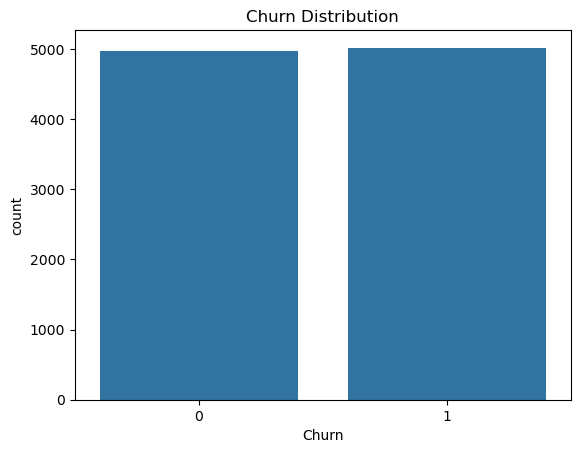

In [4]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

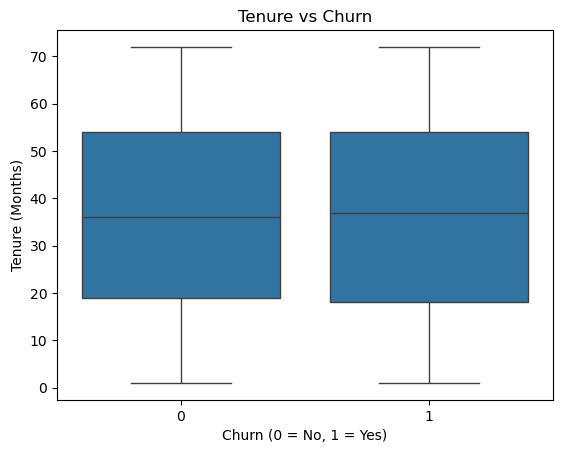

In [5]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure (Months)")
plt.show()

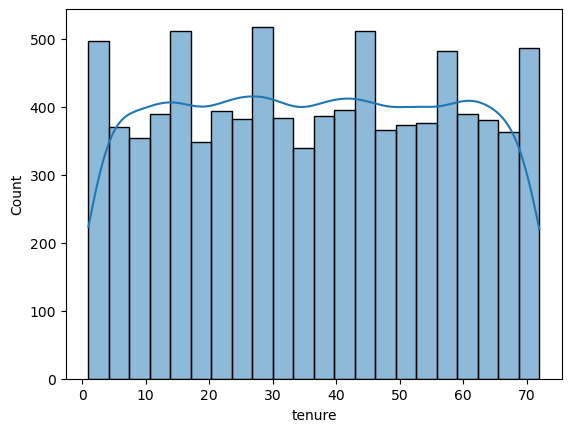

In [6]:
sns.histplot(df['tenure'], kde=True)
plt.show()

<Axes: xlabel='tenure'>

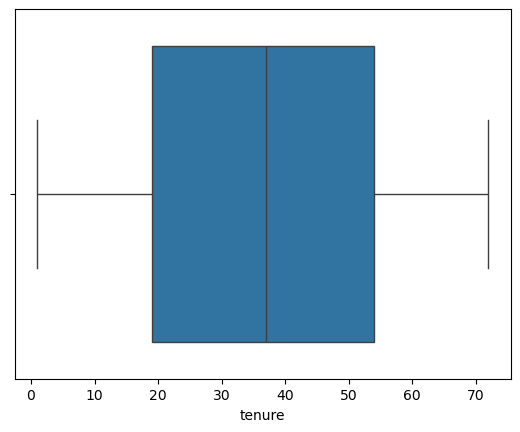

In [7]:
sns.boxplot(x=df['tenure'])

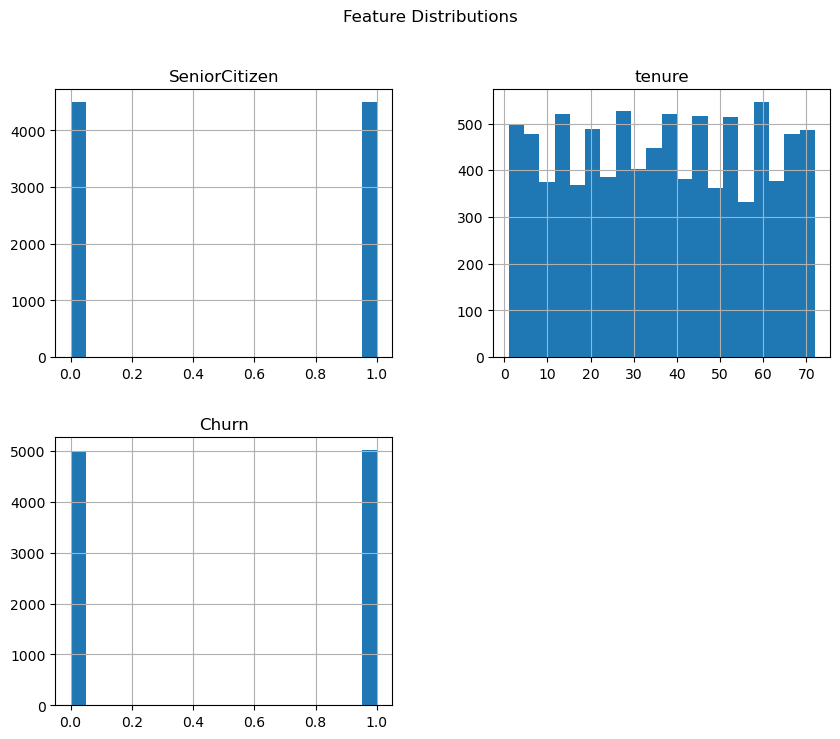

In [8]:
df.hist(figsize=(10, 8), bins=20)
plt.suptitle("Feature Distributions")
plt.show()

In [9]:
# Drop ID
df = df.drop(columns=['customerID'], errors='ignore')

# Handle missing values: fill 'tenure' NaN with mean
df['tenure'] = df['tenure'].fillna(df['tenure'].mean())

# Handle missing values: fill other categorical NaNs with mode
columns_to_fill_mode = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup']
for col in columns_to_fill_mode:
    df[col] = df[col].fillna(df[col].mode()[0])

# Convert binary categorical columns to numeric (0 or 1)
df['gender'] = df['gender'].map({'Male':1, 'Female':0})
df['Partner'] = df['Partner'].map({'Yes':1, 'No':0})
df['Dependents'] = df['Dependents'].map({'Yes':1, 'No':0})
df['PhoneService'] = df['PhoneService'].map({'Yes':1, 'No':0})

# Handle 'MultipleLines', 'OnlineSecurity', 'OnlineBackup' special values which include 'No internet service' or 'No phone service'
df['MultipleLines'] = df['MultipleLines'].replace({'Yes':1, 'No':0, 'No phone service':0})
df['OnlineSecurity'] = df['OnlineSecurity'].replace({'Yes':1, 'No':0, 'No internet service':0})
df['OnlineBackup'] = df['OnlineBackup'].replace({'Yes':1, 'No':0, 'No internet service':0})

# InternetService is a nominal categorical column with multiple values. Use one-hot encoding.
df = pd.get_dummies(df, columns=['InternetService'], drop_first=True, dtype=int)

# 'Churn' is already numerical (0 or 1), so no mapping is needed.

C:\Users\PC\AppData\Local\Temp\ipykernel_5600\591286373.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['MultipleLines'] = df['MultipleLines'].replace({'Yes':1, 'No':0, 'No phone service':0})
C:\Users\PC\AppData\Local\Temp\ipykernel_5600\591286373.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['OnlineSecurity'] = df['OnlineSecurity'].replace({'Yes':1, 'No':0, 'No internet service':0})
C:\Users\PC\AppData\Local\Temp\ipykernel_5600\591286373.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and w

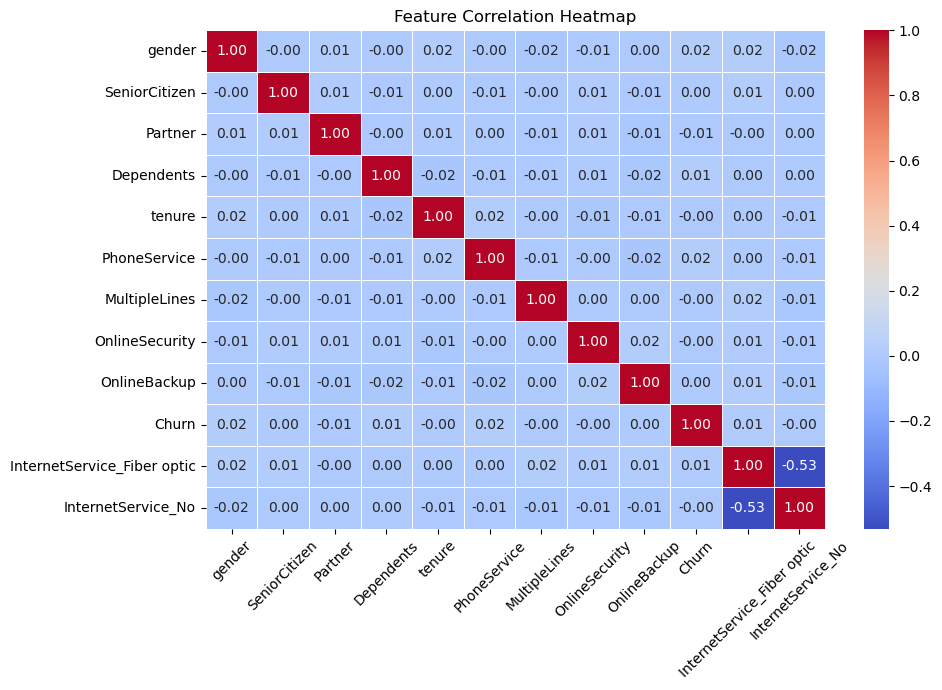

In [10]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Insights from Data Visualization
- The churn distribution is nearly balanced.
- Customers with lower tenure tend to churn more.
- Correlation heatmap shows tenure has strong influence.
- Other features have weak/moderate correlation.


In [11]:
df.isnull().sum()

gender                         0
SeniorCitizen                  0
Partner                        0
Dependents                     0
tenure                         0
PhoneService                   0
MultipleLines                  0
OnlineSecurity                 0
OnlineBackup                   0
Churn                          0
InternetService_Fiber optic    0
InternetService_No             0
dtype: int64

In [12]:
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

In [13]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop('Churn', axis=1))

### Data Preprocessing

- Missing values handled using mean/mode.
- Categorical variables converted to numerical.
- Scaling applied using StandardScaler.

In [14]:
X = df_scaled
y = df['Churn']

model = DecisionTreeClassifier()
model.fit(X, y)

print(model.feature_importances_)

[0.05130865 0.06483755 0.0508703  0.04750343 0.41180331 0.00060429
 0.08640205 0.07791009 0.08022274 0.06474648 0.06379109]


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
# 70-30 split
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [16]:
from imblearn.over_sampling import RandomOverSampler

ROS = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ROS.fit_resample(X_train, y_train)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train_res)

LogisticRegression()

In [19]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [20]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.491
              precision    recall  f1-score   support

           0       0.48      0.49      0.49       985
           1       0.50      0.49      0.50      1015

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



In [21]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt_model.fit(X_train_scaled, y_train_res)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 5]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5
)

grid_search.fit(X_train_scaled, y_train_res)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [23]:
best_dt = grid_search.best_estimator_

y_pred_dt = best_dt.predict(X_test_scaled)

### Hyperparameter Tuning

GridSearchCV was used to find optimal parameters.
The tuned Decision Tree improves performance compared to default model.

In [24]:
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Results (Tuned)")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Results (Tuned)
Accuracy: 0.512
              precision    recall  f1-score   support

           0       0.50      0.55      0.53       985
           1       0.52      0.47      0.50      1015

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



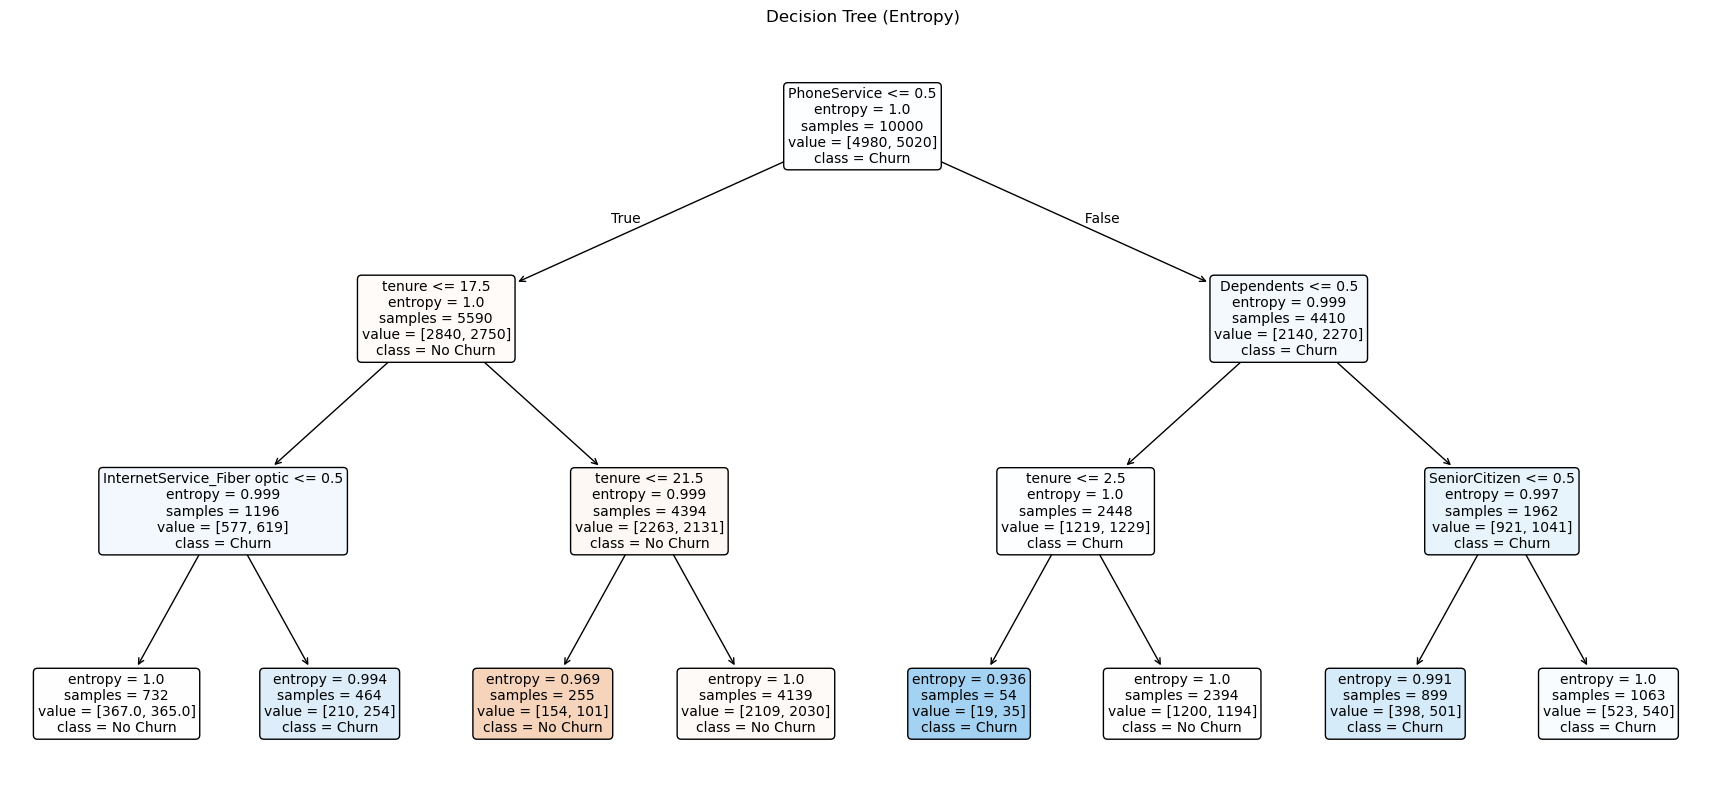

In [26]:
# Features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# If you have categorical columns (like gender), encode them
X = pd.get_dummies(X, drop_first=True)

# Train Decision Tree using ENTROPY
model = DecisionTreeClassifier(
    criterion="entropy",   # 🔥 changed from 'gini' to 'entropy'
    max_depth=3,           # adjust if needed to match your tree
    random_state=42
)

model.fit(X, y)

from sklearn.tree import plot_tree
# Plot the tree
plt.figure(figsize=(22, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.savefig("decision_tree.png", dpi=300, bbox_inches='tight')
plt.title("Decision Tree (Entropy)")
plt.show()